In [2]:
!pip install lime

DEPRECATION: Loading egg at /home/rogfel/projects/cgp_cnn/env/lib/python3.12/site-packages/nvidia_nccl_cu12-2.21.5-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/rogfel/projects/cgp_cnn/env/lib/python3.12/site-packages/nvidia_curand_cu12-10.3.5.147-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/rogfel/projects/cgp_cnn/env/lib/python3.12/site-packages/filelock-3.16.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg 

In [3]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import keras
from dataset import load
# LIME explanation with preprocessing that matches training
from lime import lime_image
from skimage.segmentation import mark_boundaries

2025-09-11 11:05:04.495251: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-11 11:05:04.501615: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-11 11:05:04.573158: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-11 11:05:04.637613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757599504.709465   61910 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757599504.73

In [4]:
# Force CPU-only execution to avoid CUDA errors
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception:
    pass

# Configure dataset path
load.PATH_DATASET = 'dataset/PetImages/'

# Locate a saved model (defaults to resnet18 if present)
def find_model(default='resnet_model_resnet34.h5'):
    if os.path.exists(default):
        return default
    candidates = sorted(glob.glob('resnet_model_*.h5'), key=os.path.getmtime, reverse=True)
    if candidates:
        return candidates[0]
    raise FileNotFoundError('No resnet_model_*.h5 found in the current directory.')

MODEL_PATH = find_model()
print('Using model:', MODEL_PATH)
model = keras.models.load_model(MODEL_PATH, compile=False)
model.summary()


2025-09-11 11:05:10.687918: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-09-11 11:05:10.687947: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: rogfel-Dell-G15-5530
2025-09-11 11:05:10.687953: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: rogfel-Dell-G15-5530
2025-09-11 11:05:10.688026: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 535.247.1
2025-09-11 11:05:10.688041: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 535.247.1
2025-09-11 11:05:10.688044: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 535.247.1


Using model: resnet_model_resnet34.h5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      9,472 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 31, 31,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 31, 31,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 31, 31,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 31, 31,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 31, 31,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 31, 31,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 31, 31,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 31, 31,    │     36,928 │ re_lu_3[0][0]   

 Total params: 21,311,234 (81.30 MB)

 Trainable params: 21,294,210 (81.23 MB)

 Non-trainable params: 17,024 (66.50 KB)

In [5]:
# Load validation data in NHWC for Keras
images_val_chw, labels_val, class_names = load.data('val')
# Convert CHW -> HWC
images_val = np.transpose(images_val_chw, (0, 2, 3, 1))
print('Validation set:', images_val.shape, labels_val.shape)
print('Classes:', class_names)

# Denormalize for visualization and LIME baseline image
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
images_val_denorm = images_val * std + mean
images_val_uint8 = np.clip(images_val_denorm * 255.0, 0, 255).astype(np.uint8)



Validation set: (202, 64, 64, 3) (202,)
Classes: ['Cat', 'Dog']


Explaining index: 17 True label: 0 Cat


100%|██████████| 100/100 [00:00<00:00, 143.35it/s]


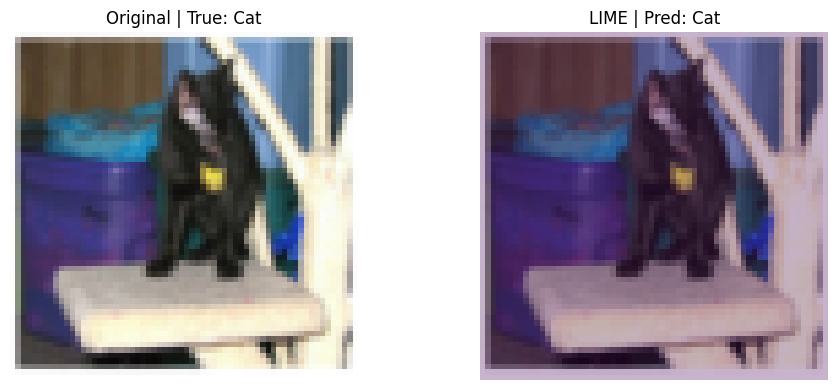

In [10]:
# Predict function matching training pipeline: torch-like norm, then model's internal /255
# During training, input to model was (x - mean)/std, then first layer divides by 255.
# So here, from uint8 images U:[0..255], we do: x=U/255 -> norm=(x-mean)/std -> feed 255*norm

def predict_fn(images_uint8: np.ndarray) -> np.ndarray:
    x = images_uint8.astype('float32') / 255.0
    norm = (x - mean) / std
    model_input = norm * 255.0
    return model.predict(model_input, verbose=0)

explainer = lime_image.LimeImageExplainer()

sample_idx = 17
sample_image = images_val_uint8[sample_idx]
sample_label = int(labels_val[sample_idx])
print('Explaining index:', sample_idx, 'True label:', sample_label, class_names[sample_label])

explanation = explainer.explain_instance(
    sample_image,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=100
)

pred_top = int(np.argmax(predict_fn(sample_image[None, ...])[0]))
image_lime, mask = explanation.get_image_and_mask(
    label=pred_top,
    positive_only=True,
    hide_rest=False,
    num_features=10,
    min_weight=0.05
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_image)
axes[0].set_title(f'Original | True: {class_names[sample_label]}')
axes[0].axis('off')
# axes[1].imshow(mark_boundaries(image_lime, mask))
axes[1].imshow(image_lime)
axes[1].imshow(mask, alpha=0.3)
axes[1].set_title(f'LIME | Pred: {class_names[pred_top]}')
axes[1].axis('off')
plt.tight_layout()
plt.show()
